In [1]:
import numpy as np

spe_perm = np.loadtxt("./spe_perm.dat", dtype=float).reshape(
    3, 85, 220, 60
)  # Milli Darcy
spe_perm *= 9.869233e-16  # To SI
spe_phi = np.loadtxt("./spe_phi.dat", dtype=float).reshape(85, 220, 60)
spe_phi.shape

(85, 220, 60)

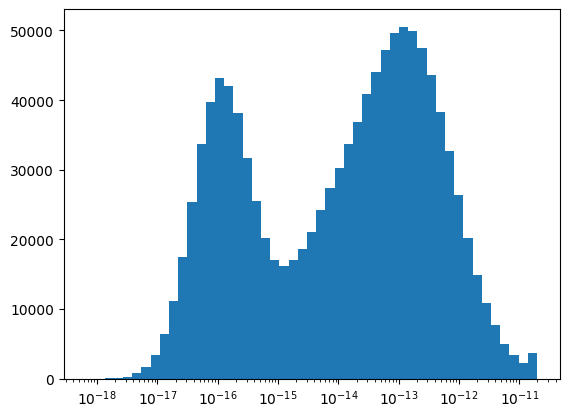

In [12]:
from matplotlib import pyplot as plt

data = spe_perm[1]
bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)
plt.hist(data.ravel(), bins=bins)
plt.xscale('log')

In [48]:
# z_ranges = [[0, 20], [10, 30], [20, 40], [30, 50], [40, 60]]
# x_ranges = [[0, 42], [21, 63] [42, 84]]

In [62]:
spe_perm = spe_perm[:, :30, :31, :32]
spe_phi = spe_phi[:30, :31, :32]

In [65]:
np.save('./spe_perm.npy', spe_perm)
np.save('./spe_phi.npy', spe_phi)

# Export for ParaView

In [51]:
!pip install vtk

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [57]:
import numpy as np
import vtk
from vtk.util import numpy_support

def export_to_vti(path, data):
    # Convert to VTK image data
    image = vtk.vtkImageData()
    image.SetDimensions(data.shape[::-1])  # (X, Y, Z)
    image.SetSpacing(1.0, 1.0, 1.0)
    image.SetOrigin(0.0, 0.0, 0.0)

    # Convert numpy array to VTK array
    vtk_data = numpy_support.numpy_to_vtk(num_array=data.ravel(order="C"), deep=True)
    vtk_data.SetName("values")

    # Attach data to image
    image.GetPointData().SetScalars(vtk_data)

    # Write to .vti
    writer = vtk.vtkXMLImageDataWriter()
    writer.SetFileName(path)
    writer.SetInputData(image)
    writer.Write()
    print("Saved to", path)

export_to_vti('./spe_perm.vti', spe_perm[0])
export_to_vti('./spe_phi.vti', spe_phi)

Saved to ./spe_perm.vti
Saved to ./spe_phi.vti
